# Uncertainty-Aware Time Series Forecasting with ProbPipe

This example demonstrates how to build a **Bayesian forecasting pipeline** using ProbPipe's modular workflow system.

**What you'll learn:**
- How to compose probabilistic workflows from reusable nodes
- How uncertainty propagates through the pipeline (distributions, not just point estimates)
- How to build a Bayesian linear regression forecaster with automatic uncertainty quantification

**The Pipeline:**
```
DataLoader → TrainTestSplit → FeatureEngineering → BayesianInference → Prediction → Diagnostics
```

In [1]:
# Visual pipeline structure
print("""
PM2.5 Data (Beijing Air Quality)
   ↓
Train/Test Split (2 weeks forecast horizon)
   ↓
Seasonal Features (hourly + yearly cycles)
   ↓
Bayesian Linear Regression (conjugate prior)
   ↓
Posterior Distribution (β, σ)
   ↓
Posterior Predictive Samples
   ↓
Coverage Diagnostics & Visualization
""")


PM2.5 Data (Beijing Air Quality)
   ↓
Train/Test Split (2 weeks forecast horizon)
   ↓
Seasonal Features (hourly + yearly cycles)
   ↓
Bayesian Linear Regression (conjugate prior)
   ↓
Posterior Distribution (β, σ)
   ↓
Posterior Predictive Samples
   ↓
Coverage Diagnostics & Visualization



In [2]:
from probpipe.core.node import Node, wf, abstractwf, Workflow, Module, AbstractModule
from probpipe import Gaussian
from probpipe import EmpiricalDistribution, Distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from abc import ABC


## 1. Core Abstractions: What is a "Bayesian Forecasting Pipeline"?

The essence of Bayesian forecasting is captured by two key operations:

1. **Inference**: Learn a posterior distribution over model parameters from training data
2. **Prediction**: Generate forecasts by sampling from the posterior predictive distribution

We define these as abstract interfaces so the `ForecastingModule` can work with different Bayesian methods (MCMC, variational inference, conjugate models, etc.).

**Everything else** (data loading, preprocessing, diagnostics) will be concrete implementations specific to this example.

In [3]:
class InferenceMethod(AbstractModule):
    """
    Abstract interface for Bayesian inference.
    
    Takes training data and returns a posterior distribution over parameters.
    Different implementations could use: conjugate priors, MCMC, variational inference, etc.
    """
    @abstractwf
    def infer(self, X_train, y_train: EmpiricalDistribution) -> Distribution:
        ...

class PosteriorPredictive(AbstractModule):
    """
    Abstract interface for generating predictions from a posterior.
    
    Takes a posterior distribution and test inputs, returns predictive distribution.
    This is where uncertainty from parameters propagates to predictions.
    """
    @abstractwf
    def predict(self, posterior: Distribution, X_test) -> EmpiricalDistribution:
        ...

## 2. Data & Preprocessing Nodes

These are concrete implementations specific to our PM2.5 forecasting example.
They handle data loading, train/test splitting, and feature engineering.

**Note:** These inherit from `Module` (not `Node`) so their `@wf` methods get automatic dependency injection. Only `Module` has the machinery to build workflows - `Node` is just a base container.

In [4]:
# import the dataset from UC Irvine's data repository
from ucimlrepo import fetch_ucirepo 
# if not installed yet: pip install ucimlrepo

In [5]:
class PM25DataLoaderNode(Module):
    """Loads PM2.5 air quality data from Beijing (UCI repository)."""
    
    def __init__(self, dataset_id: int | None = None, csv_path: str | None = None):
        super().__init__(dataset_id=dataset_id, csv_path=csv_path)

    @wf
    def load(self, dataset_id: int | None = None, csv_path: str | None = None):
        if csv_path:
            df = pd.read_csv(csv_path)
        elif dataset_id is not None:
            dataset = fetch_ucirepo(id=int(dataset_id))
            df = dataset.data.original  
        else:
            raise ValueError("Either enter an id or csv file path")

        timestamps = pd.to_datetime(df[["year", "month", "day", "hour"]]).to_numpy()

        pm25 = df["pm2.5"].replace(-999, np.nan).astype(float)
        mask = ~pm25.isna()

        y = pm25[mask].to_numpy()
        ts = timestamps[mask]

        return ts, EmpiricalDistribution(y[None, :])

### Train/Test Split

In [6]:
class TrainTestSplitNode(Module):
    """Splits time series into training and test segments."""

    def __init__(self, test_horizon: int):
        super().__init__(test_horizon=int(test_horizon))

    @wf
    def split(self, timestamps, y: EmpiricalDistribution, test_horizon: int):
        y_samples = y.samples
        T = y_samples.shape[1]
        H = int(test_horizon) 

        if H <= 0 or H >= T:
            raise ValueError("Invalid test horizon.")

        split_idx = T - H
        ts_train, ts_test = timestamps[:split_idx], timestamps[split_idx:]
        y_train, y_test = y_samples[:, :split_idx], y_samples[:, split_idx:]

        return ts_train, EmpiricalDistribution(y_train), ts_test, EmpiricalDistribution(y_test)

### Seasonal Feature Engineering

We model PM2.5 as a linear function of time with seasonal patterns:

$$ y_t = \beta_0 + \beta_1 t + \beta_2 \sin(\frac{2\pi t}{24}) + \beta_3 \cos(\frac{2\pi t}{24}) + \beta_4 \sin(\frac{2\pi t}{365 \times 24}) + \beta_5 \cos(\frac{2\pi t}{365 \times 24}) + \epsilon_t$$

where $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$

The model includes: intercept, linear trend, daily cycle (24h), and yearly cycle (365 days).

In [7]:
class SeasonalFeatureNode(Module):
    """Constructs design matrices with seasonal features."""
    
    def __init__(self):
        super().__init__()
        
    @wf
    def build(self, ts_train, ts_test):
        n_train = len(ts_train)
        n_test = len(ts_test)

        t_train = np.arange(n_train)
        t_test = np.arange(n_train, n_train + n_test)

        def design(t):
            return np.column_stack([
                np.ones_like(t, dtype=float),        # intercept
                t.astype(float),                      # linear trend
                np.sin(2*np.pi*t/24.0),              # daily cycle (sin)
                np.cos(2*np.pi*t/24.0),              # daily cycle (cos)
                np.sin(2*np.pi*t/(365.0*24.0)),      # yearly cycle (sin)
                np.cos(2*np.pi*t/(365.0*24.0)),      # yearly cycle (cos)
            ])

        return design(t_train), design(t_test)

## 3. Bayesian Model Implementation

Now we implement the two core abstractions:

1. **`ConjugateBLRInferenceNode`** implements `InferenceMethod` using conjugate Normal-Inverse-Gamma prior
2. **`PosteriorPredictiveNode`** implements `PosteriorPredictive` to generate forecasts

This demonstrates ProbPipe's key feature: **distributions flow through the pipeline**, not just point estimates.

In [8]:
class ConjugateBLRInferenceNode(InferenceMethod):
    """
    Bayesian linear regression with conjugate Normal-Inverse-Gamma prior.
    
    Implements the InferenceMethod interface using closed-form conjugate updates.
    Returns an EmpiricalDistribution of posterior samples with shape (S, D+1),
    where the last column is σ (noise std dev) and first D columns are β (coefficients).
    """

    def __init__(self, num_samples=2000, a0=2.0, b0=2.0, v0_scale=10.0):
        super().__init__(
            num_samples=int(num_samples),
            a0=float(a0),
            b0=float(b0),
            v0_scale=float(v0_scale),
        )

    @wf
    def infer(self, X_train, y_train: EmpiricalDistribution, num_samples: int, a0: float, b0: float, v0_scale: float):
        X = np.asarray(X_train)
        y = y_train.samples[0]   # shape (N,)

        N, D = X.shape

        # Prior: β | σ² ~ N(m₀, σ²V₀), σ² ~ InvGamma(a₀, b₀)
        m0 = np.zeros(D)
        V0 = (v0_scale**2) * np.eye(D)
        V0_inv = np.linalg.inv(V0)

        # Posterior parameters (conjugate update)
        XtX = X.T @ X
        Vn_inv = V0_inv + XtX
        Vn = np.linalg.inv(Vn_inv)

        Xty = X.T @ y
        mn = Vn @ (V0_inv @ m0 + Xty)

        a_n = a0 + N / 2.0
        yty = float(y.T @ y)
        m0_term = float(m0.T @ V0_inv @ m0)
        mn_term = float(mn.T @ Vn_inv @ mn)
        b_n = b0 + 0.5 * (yty + m0_term - mn_term)

        # Sample from posterior
        gamma = np.random.gamma(shape=a_n, scale=1.0/b_n, size=num_samples)
        sigma2 = 1.0 / gamma
        sigma = np.sqrt(sigma2)

        L = np.linalg.cholesky(Vn)
        z = np.random.normal(size=(num_samples, D))
        beta = mn[None, :] + sigma[:, None] * (z @ L.T)

        samples = np.column_stack([beta, sigma])
        return EmpiricalDistribution(samples)

### Posterior Predictive Implementation

In [9]:
class PosteriorPredictiveNode(PosteriorPredictive):
    """
    Generates posterior predictive samples by propagating parameter uncertainty.
    
    Implements the PosteriorPredictive interface.
    For each posterior sample of (β, σ), computes predictions and adds noise.
    """
    def __init__(self):
        super().__init__()
    
    @wf
    def predict(self, posterior: EmpiricalDistribution, X_test):
        post = posterior.samples  # shape (S, D+1)
        X = np.asarray(X_test)

        beta = post[:, :-1]  # coefficients
        sigma = post[:, -1]   # noise std dev

        # For each posterior sample, compute mean prediction and add noise
        mu = beta @ X.T
        noise = np.random.normal(size=mu.shape) * sigma[:, None]
        y_pred = mu + noise

        return EmpiricalDistribution(y_pred)

## 4. Utilities & Diagnostics

Additional nodes for evaluation and approximation (optional features).

In [10]:
class GaussianApproximationNode(Module):
    """
    Converts any Distribution into a multivariate Gaussian (moment matching).
    Useful for fast approximate inference pipelines.
    """
    def __init__(self, num_samples: int = 2048):
        super().__init__(num_samples=int(num_samples))

    @wf
    def approximate(self, posterior: Distribution, num_samples: int) -> Gaussian:
        return Gaussian.from_distribution(posterior, num_samples=num_samples)

### Coverage Diagnostics

In [11]:
class CoverageDiagnosticsNode(Module):
    """
    Evaluates predictive interval coverage (calibration check).
    Compares nominal vs empirical coverage at different confidence levels.
    """

    def __init__(self, levels=(0.5, 0.8, 0.9)):
        super().__init__(levels=tuple(levels))

    @wf
    def diagnose(self, predictive: EmpiricalDistribution, y_true: EmpiricalDistribution, plot: bool=True, levels=(0.5,0.8,0.9)):
        samples = predictive.samples
        y = y_true.samples[0]

        coverages = {}
        for lvl in levels:
            lo = np.quantile(samples, (1-lvl)/2, axis=0)
            hi = np.quantile(samples, 1-(1-lvl)/2, axis=0)
            coverages[lvl] = float(((y >= lo) & (y <= hi)).mean())

        if plot:
            xs = np.array(list(coverages.keys()))
            ys = np.array(list(coverages.values()))

            plt.figure(figsize=(5,5))
            plt.plot(xs, ys, "o-", label="Empirical")
            plt.plot([0,1], [0,1], "--", label="Ideal")
            plt.xlabel("Nominal Coverage")
            plt.ylabel("Empirical Coverage")
            plt.title("Predictive Interval Coverage")
            plt.legend()
            plt.tight_layout()
            plt.show()

        return coverages

## 5. Forecasting Module (Orchestration)

The `PM25ForecastingModule` orchestrates the entire pipeline by composing workflow methods.

**Key ProbPipe features demonstrated:**
1. **Automatic dependency resolution**: The Module wires together child nodes based on type hints
2. **Reusable workflows**: Each `@wf` method can be called independently or composed
3. **Distribution-aware**: Nodes pass `Distribution` objects, preserving uncertainty

The Module defines three main workflows:
- `fit()`: trains the Bayesian model → returns posterior distribution
- `predict()`: generates forecasts with uncertainty → returns predictive distribution  
- `diagnose()`: evaluates prediction quality → returns coverage metrics

In [12]:
class PM25ForecastingModule(Module):
    """
    Orchestrates the complete forecasting pipeline.
    
    This Module composes data preprocessing, Bayesian inference, and prediction
    into reusable workflow methods. Child nodes are automatically wired based on
    parameter type hints.
    """

    @wf
    def fit(
        self,
        data: Node,                    # data loader
        split: Node,                   # train/test splitter
        features: Node,                # feature engineering
        inference: InferenceMethod,    # Bayesian inference (abstract interface)
    ) -> Distribution:
        """Train the Bayesian model and return posterior distribution."""
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        X_tr, X_te = features.build(ts_train=ts_tr, ts_test=ts_te)
        return inference.infer(X_train=X_tr, y_train=y_tr)

    @wf
    def predict(
        self,
        data: Node,                          # data loader
        split: Node,                         # train/test splitter
        features: Node,                      # feature engineering
        ppred: PosteriorPredictive,         # posterior predictive (abstract interface)
        posterior: Distribution,             # posterior from fit()
    ) -> EmpiricalDistribution:
        """Generate forecasts with uncertainty from posterior."""
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        X_tr, X_te = features.build(ts_train=ts_tr, ts_test=ts_te)
        return ppred.predict(posterior=posterior, X_test=X_te)

    @wf
    def diagnose(
        self,
        data: Node,                          # data loader
        split: Node,                         # train/test splitter
        diag: Node,                          # diagnostics
        predictive: EmpiricalDistribution,   # predictions from predict()
    ):
        """Evaluate prediction quality."""
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        return diag.diagnose(predictive=predictive, y_true=y_te, plot=True)

    @wf
    def fit_gaussian(
        self,
        data: Node,
        split: Node,
        features: Node,
        inference: InferenceMethod,
        approx: Node,                        # Gaussian approximation
    ) -> Gaussian:
        """Train model and return Gaussian approximation of posterior."""
        posterior_emp = self.fit(data=data, split=split, features=features, inference=inference)
        return approx.approximate(posterior=posterior_emp)

### Helper functions

In [13]:
def plot_forecast_with_uncertainty(
    predictive,
    y_true,
    *,
    title="PM2.5 Forecast with Predictive Uncertainty",
    ylabel="PM2.5",
    xlabel="Time (test window)",
):
    """
    Plots posterior predictive mean and uncertainty bands.

    Args:
        predictive: EmpiricalDistribution with samples shape (S, T)
        y_true: EmpiricalDistribution with samples shape (1, T)
    """
    samples = predictive.samples          # (S, T)
    y = y_true.samples[0]                  # (T,)

    t = np.arange(len(y))

    # Predictive summaries
    mean = samples.mean(axis=0)
    lo_80 = np.quantile(samples, 0.10, axis=0)
    hi_80 = np.quantile(samples, 0.90, axis=0)
    lo_90 = np.quantile(samples, 0.05, axis=0)
    hi_90 = np.quantile(samples, 0.95, axis=0)

    plt.figure(figsize=(10, 4))

    # Uncertainty bands
    plt.fill_between(t, lo_90, hi_90, color="C0", alpha=0.20, label="90% credible interval")
    plt.fill_between(t, lo_80, hi_80, color="C0", alpha=0.35, label="80% credible interval")

    # Mean prediction
    plt.plot(t, mean, color="C0", lw=2, label="Posterior predictive mean")

    # Observed data
    plt.plot(t, y, color="black", lw=1.5, label="Observed PM2.5")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

## 6. Build the Pipeline

Now we instantiate the nodes and compose them into a Module.

In [14]:
# Instantiate nodes with configuration
data = PM25DataLoaderNode(dataset_id=381)           # Beijing PM2.5 dataset
split = TrainTestSplitNode(test_horizon=24*14)      # 2-week forecast horizon
features = SeasonalFeatureNode()                     # Daily + yearly seasonality
inference = ConjugateBLRInferenceNode(num_samples=3000)  # Bayesian linear regression
ppred = PosteriorPredictiveNode()                    # Generate forecasts
diag = CoverageDiagnosticsNode()                     # Evaluate calibration

### Compose into a Module

**Two equivalent ways to create a Module:**

**Old style** (explicit): Pass `child_nodes` dict
**New style** (recommended): Pass nodes directly as kwargs - they're auto-detected

The Module automatically identifies which kwargs are Nodes (become child_nodes) vs regular values (become inputs).

In [15]:
# Create the module (new style - nodes passed as kwargs)
pipe = PM25ForecastingModule(
    data=data,
    split=split,
    features=features,
    inference=inference,
    ppred=ppred,
    diag=diag,
    approx=GaussianApproximationNode(),
    workflow_kind=None,  # None = pure Python, or "task"/"flow" for Prefect
)

# The module automatically wires these nodes to its workflow methods based on type hints!

### Optional: Prefect Integration

**Out-of-the-box feature:** The same workflow code can run as Prefect tasks/flows without modification!

Set `workflow_kind="task"` or `workflow_kind="flow"` when creating the Module to enable orchestration, monitoring, and caching via Prefect.

This demonstrates ProbPipe's flexibility: prototype in pure Python, deploy with production orchestration using the same code.

## 7. Run the Pipeline

Now we execute the three main workflows:
1. **`fit()`**: Train the model → get posterior distribution  
2. **`predict()`**: Generate forecasts → get predictive distribution
3. **`diagnose()`**: Evaluate calibration → get coverage metrics

**Key observation:** Notice how distributions flow between nodes, preserving uncertainty throughout the pipeline!

Posterior shape: (3000, 7)
Predictive shape: (3000, 336)


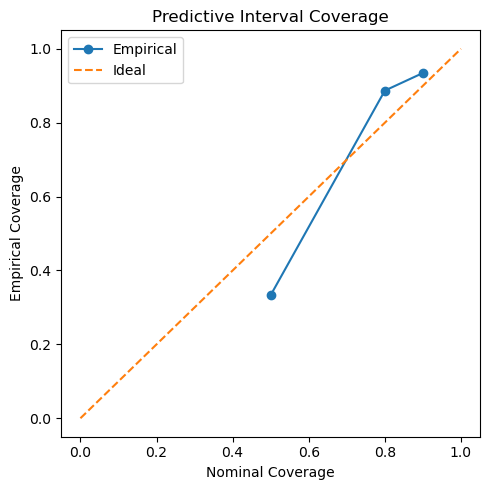

Coverage metrics: {0.5: 0.3333333333333333, 0.8: 0.8869047619047619, 0.9: 0.9345238095238095}


In [16]:
# 1. Fit: Learn posterior distribution P(β, σ | data)
posterior_emp = pipe.fit()
print(f"Posterior shape: {posterior_emp.samples.shape}")  # (3000 samples, 7 params: 6 betas + 1 sigma)

# 2. Predict: Generate forecasts with uncertainty
predictive1 = pipe.predict(posterior=posterior_emp)
print(f"Predictive shape: {predictive1.samples.shape}")  # (3000 samples, 336 time points)

# 3. Diagnose: Check if uncertainty is well-calibrated
coverage = pipe.diagnose(predictive=predictive1)
print(f"Coverage metrics: {coverage}")

## 8. Visualization

Let's visualize the forecasts with uncertainty bands.

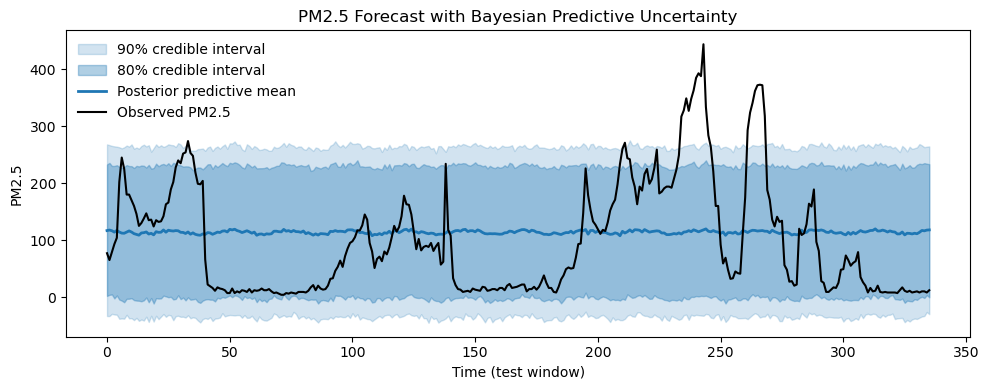

In [18]:
ts, y = data.load()
ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)

plot_forecast_with_uncertainty(
    predictive=predictive1,
    y_true=y_te,
    title="PM2.5 Forecast with Bayesian Predictive Uncertainty",
)

## 9. Dependency Graph Visualization

ProbPipe automatically tracks dependencies between nodes and workflows.

The DAG shows:
- **Ellipses**: Child nodes (outside the module)
- **Boxes**: Workflow methods (inside the module)  
- **Edges**: Dependencies (from node to workflow that uses it)

This is a **dependency graph**, not a call graph - it shows what each workflow *needs*, not execution order.

In [19]:
dot = pipe.dag()

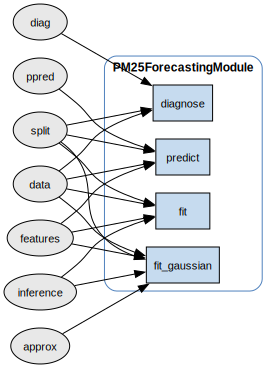

In [20]:
display(pipe.dag())

## Summary

This example showed how ProbPipe makes it easy to build modular Bayesian pipelines:

**Core Features Used:**
1. **Node composition**: Each step (data loading, inference, prediction) is a reusable `Node`
2. **Distribution-first design**: Uncertainty flows through the pipeline as `Distribution` objects
3. **Automatic dependency wiring**: The `Module` connects nodes based on type hints
4. **Abstract interfaces**: `InferenceMethod` and `PosteriorPredictive` define what "Bayesian forecasting" means
5. **Flexible execution**: Same code runs as pure Python or Prefect workflows

**Why this matters:**
- **Modularity**: Swap out inference methods (MCMC, VI, conjugate) without changing the pipeline
- **Uncertainty propagation**: No manual bookkeeping of samples/distributions
- **Composability**: Workflow methods can be called independently or chained
- **Production-ready**: Optional Prefect integration for orchestration and monitoring
